# Judge Score Comparison Plots

지정한 디렉토리에서 `judge_{model}_*.json` 파일들을 읽어, 같은 `k`와 같은 `question_session`에 대한 평균 점수를 모델별로 비교하는 꺾은선그래프를 그립니다.

In [1]:
import os
import json
import glob
from collections import defaultdict
from statistics import mean

import matplotlib.pyplot as plt

## Detail JSON → CSV 정리

`SOURCE_DIR` 아래의 `judge_*.json` 파일들을 읽어 (module, config) 폴더별 한 행씩 모아 `judge_summary.csv`로 저장합니다.
열은 `avg_` 접두어 없이 다음 순서로 출력됩니다:

`module_config, total, violation, acknowledgement, hallucination, helpful, violation_score_0, violation_score_1, acknowledgement_score_0, acknowledgement_score_1, hallucination_score_0, hallucination_score_1, helpful_score_0, helpful_score_1, num_qa, num_valid_qa, num_failed_qa`

In [2]:
import csv

SOURCE_DIR = "Qwen3-1.7B_judge_gpt-4o-mini"   # 입력 경로: judge_*.json 들이 있는 디렉토리
OUTPUT_CSV = os.path.join(SOURCE_DIR, "judge_summary.csv")

_SUBDIMS = ["violation", "acknowledgement", "hallucination", "helpful"]
_CSV_COLS = (
    ["module_config", "total"]
    + _SUBDIMS
    + [f"{s}_score_{v}" for s in _SUBDIMS for v in (0, 1)]
    + ["num_qa", "num_valid_qa", "num_failed_qa"]
)


def _filled(v):
    return isinstance(v, int) and v >= 0


def _row_from_detail(detail):
    qa = detail.get("qa_entries", [])
    eligible = [q for q in qa if q.get("judge_eligible")]
    valid    = [q for q in eligible if all(_filled(q.get(s)) for s in _SUBDIMS)]
    row = {
        "module_config": f"{detail['module']}_{detail['config_num']}",
        "num_qa":        len(qa),
        "num_valid_qa":  len(valid),
        "num_failed_qa": len(eligible) - len(valid),
    }
    for s in _SUBDIMS:
        scores = [int(q[s]) for q in valid]
        row[s] = round(mean(scores), 4) if scores else ""
        row[f"{s}_score_0"] = sum(1 for v in scores if v == 0)
        row[f"{s}_score_1"] = sum(1 for v in scores if v == 1)
    if valid:
        totals = [sum(int(q[s]) for s in _SUBDIMS) for q in valid]
        row["total"] = round(mean(totals), 4)
    else:
        row["total"] = ""
    return row


rows = []
for path in sorted(glob.glob(os.path.join(SOURCE_DIR, "judge_*.json"))):
    with open(path, "r") as f:
        detail = json.load(f)
    if "qa_entries" not in detail or "module" not in detail or "config_num" not in detail:
        print(f"  [skip] {os.path.basename(path)} — missing module/config_num/qa_entries")
        continue
    rows.append(_row_from_detail(detail))

rows.sort(key=lambda r: r["module_config"])

with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=_CSV_COLS)
    writer.writeheader()
    writer.writerows(rows)

print(f"wrote {len(rows)} rows → {OUTPUT_CSV}")
for r in rows:
    print(f"  {r['module_config']}: total={r['total']}  valid={r['num_valid_qa']}/{r['num_qa']}")

wrote 6 rows → Qwen3-1.7B_judge_gpt-4o-mini/judge_summary.csv
  amem_0: total=1.3859  valid=5050/5050
  gmem_1: total=2.2105  valid=5050/5050
  ldagent_0: total=1.1428  valid=5021/5050
  memorybank_0: total=1.2096  valid=5043/5050
  ubllm_0: total=1.32  valid=5050/5050
  theanine_0: total=1.2475  valid=5050/5050


## 설정

- `EVAL_DIR`: judge JSON 파일들이 있는 디렉토리
- `MODELS`: 비교할 모델 식별자 리스트 (`judge_{model}_*.json`의 `{model}` 부분)
- `METRIC`: 그래프에 사용할 점수 (`total`, `violation`, `acknowledgement`, `hallucination`, `helpful`)

In [10]:
EVAL_DIR = SOURCE_DIR        # 예: "nothing_4b", "nothing", ...
MODELS   = ["amem_0", "ldagent_0", "gmem_1"]  # 예: ["amem_0", "gmem_0", "theanine_0"]
METRIC   = "total"             # "total" | "violation" | "acknowledgement" | "hallucination" | "helpful"

# 두 번째 그래프에서 "고정"할 question_session.
# None 이면 question_session 별로 subplot 을 모두 그립니다.
QUESTION_SESSION = 1

SUBDIMS = ["violation", "acknowledgement", "hallucination", "helpful"]

In [11]:
def load_judge_file(eval_dir: str, model: str) -> dict:
    """`judge_{model}_*.json` 패턴에 매칭되는 파일을 찾아 로드합니다."""
    pattern = os.path.join(eval_dir, f"judge_{model}_*.json")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No judge JSON found for model '{model}' in '{eval_dir}' (pattern: {pattern})")
    if len(matches) > 1:
        print(f"[warn] multiple files matched for {model}: {matches} — using {matches[0]}")
    with open(matches[0], "r") as f:
        return json.load(f)

def entry_score(entry: dict, metric: str):
    """단일 entry에서 점수를 추출. judge_eligible=False거나 점수가 -1이면 None 반환."""
    if not entry.get("judge_eligible", True):
        return None
    if metric == "total":
        vals = [entry.get(d) for d in SUBDIMS]
        if any(v is None or v < 0 for v in vals):
            return None
        return float(sum(vals))
    v = entry.get(metric)
    if v is None or v < 0:
        return None
    return float(v)

def group_average(entries, group_key: str, metric: str, filter_fn=None):
    """entries를 group_key로 묶어 metric 평균을 계산. filter_fn(e)->bool로 사전 필터링 가능."""
    buckets = defaultdict(list)
    for e in entries:
        if filter_fn is not None and not filter_fn(e):
            continue
        s = entry_score(e, metric)
        if s is None:
            continue
        buckets[e[group_key]].append(s)
    xs = sorted(buckets.keys())
    ys = [mean(buckets[x]) for x in xs]
    return xs, ys

def all_question_sessions(model_data) -> list:
    """모든 모델 entries 에 등장하는 question_session 값들의 합집합."""
    s = set()
    for d in model_data.values():
        for e in d["qa_entries"]:
            s.add(e["question_session"])
    return sorted(s)

In [12]:
model_data = {m: load_judge_file(EVAL_DIR, m) for m in MODELS}
for m, d in model_data.items():
    n_entries = len(d.get("qa_entries", []))
    print(f"{m}: llm={d.get('llm')}, qa_entries={n_entries}")

amem_0: llm=Qwen3-1.7B, qa_entries=5050
ldagent_0: llm=Qwen3-1.7B, qa_entries=5050
gmem_1: llm=Qwen3-1.7B, qa_entries=5050


## 1. 같은 `k`에 대한 평균 점수

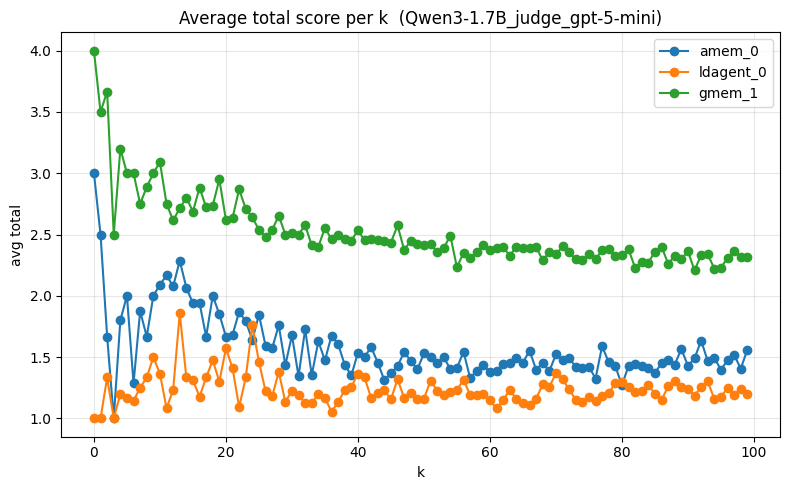

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
for m in MODELS:
    entries = model_data[m]["qa_entries"]
    xs, ys = group_average(entries, group_key="k", metric=METRIC)
    ax.plot(xs, ys, marker="o", label=m)

ax.set_xlabel("k")
ax.set_ylabel(f"avg {METRIC}")
ax.set_title(f"Average {METRIC} score per k  ({EVAL_DIR})")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 2. 고정된 `question_session`에 대해, `k`에 따른 평균 점수

`QUESTION_SESSION` 값을 정수로 지정하면 그 session 하나만,
`None` 으로 두면 모든 question_session 에 대해 subplot 으로 그립니다.
각 subplot 안에서는 x축이 `k`, 모델별로 한 줄씩 그려집니다.

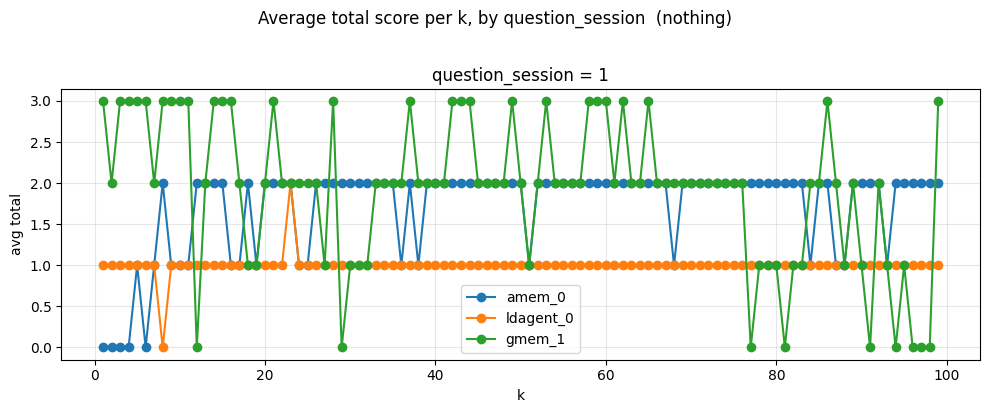

In [7]:
if QUESTION_SESSION is not None:
    sessions = [QUESTION_SESSION]
else:
    sessions = all_question_sessions(model_data)

n = len(sessions)
ncols = min(3, n)
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(10 * ncols, 4 * nrows), squeeze=False)

for idx, qs in enumerate(sessions):
    ax = axes[idx // ncols][idx % ncols]
    for m in MODELS:
        entries = model_data[m]["qa_entries"]
        xs, ys = group_average(
            entries,
            group_key="k",
            metric=METRIC,
            filter_fn=lambda e, qs=qs: e["question_session"] == qs,
        )
        ax.plot(xs, ys, marker="o", label=m)
    ax.set_xlabel("k")
    ax.set_ylabel(f"avg {METRIC}")
    ax.set_title(f"question_session = {qs}")
    ax.grid(True, alpha=0.3)
    ax.legend()

# 빈 subplot 숨기기
for idx in range(n, nrows * ncols):
    axes[idx // ncols][idx % ncols].axis("off")

fig.suptitle(f"Average {METRIC} score per k, by question_session  ({EVAL_DIR})", y=1.02)
plt.tight_layout()
plt.show()